<a href="https://colab.research.google.com/github/Mokshagnatej/Internship-Innolift-Ventures/blob/main/Cloud_watch_day_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Anomaly Detection Model Comparison

In [11]:
import pandas as pd

df = pd.read_csv("/content/dataset.csv")

df.head()

,window_length,duration_minutes,sampling_interval_minutes,value_mean,value_std,value_min,value_max,value_median,value_q25,value_q75,...,value_first,value_last,value_trend,value_abs_diff_mean,value_abs_diff_std,value_max_jump,value_energy,peak_to_mean_ratio,source_file,anomaly
0,48,235.0,5.0,20.00,0.000000,20.0,20.00,20.0,20.0,20.00,...,20.0,20.00,0.000000,0.000000,0.000000,0.0,400.0000,1.00000,artificialNoAnomaly/artificialNoAnomaly/art_da...,0
1,48,235.0,5.0,20.00,0.000000,20.0,20.00,20.0,20.0,20.00,...,20.0,20.00,0.000000,0.000000,0.000000,0.0,400.0000,1.00000,artificialNoAnomaly/artificialNoAnomaly/art_da...,0
2,48,235.0,5.0,20.00,0.000000,20.0,20.00,20.0,20.0,20.00,...,20.0,20.00,0.000000,0.000000,0.000000,0.0,400.0000,1.00000,artificialNoAnomaly/artificialNoAnomaly/art_da...,0
3,48,235.0,5.0,32.00,20.784610,20.0,68.00,20.0,20.0,32.00,...,20.0,68.00,1.125488,1.021277,6.926635,48.0,1456.0000,2.12500,artificialNoAnomaly/artificialNoAnomaly/art_da...,0
4,48,235.0,5.0,61.28,24.229305,20.0,79.52,72.8,56.0,78.08,...,20.0,79.52,1.470638,1.266383,7.032555,48.0,4342.2976,1.29765,artificialNoAnomaly/artificialNoAnomaly/art_da...,0


In [12]:
df.columns

Index(['window_length', 'duration_minutes', 'sampling_interval_minutes',
       'value_mean', 'value_std', 'value_min', 'value_max', 'value_median',
       'value_q25', 'value_q75', 'value_range', 'value_iqr', 'value_first',
       'value_last', 'value_trend', 'value_abs_diff_mean',
       'value_abs_diff_std', 'value_max_jump', 'value_energy',
       'peak_to_mean_ratio', 'source_file', 'anomaly'],
      dtype='object')

In [13]:
X = df.drop("anomaly", axis=1)
y = df["anomaly"]

print(X.shape)
print(y.shape)

(15192, 21)
(15192,)


In [14]:
X = pd.get_dummies(X, drop_first=True)

print(X.shape)

(15192, 77)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(12153, 77)
(3039, 77)


In [16]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


In [17]:
from sklearn.metrics import accuracy_score

y_pred_lr = lr.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", accuracy)

Accuracy: 0.9443896018427114


In [18]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


In [19]:
from sklearn.metrics import accuracy_score

y_pred_dt = dt.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 1.0


In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [21]:
from sklearn.metrics import accuracy_score

y_pred_rf = rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 1.0


In [22]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

print("Gradient Boosting Model Trained Successfully")

Gradient Boosting Model Trained Successfully


In [23]:
from sklearn.metrics import accuracy_score

y_pred_gb = gb.predict(X_test)

accuracy_gb = accuracy_score(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", accuracy_gb)

Gradient Boosting Accuracy: 1.0


In [24]:
import pandas as pd

results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        0.655125,
        0.571975,
        0.649450,
        0.658075
    ]
}

comparison_df = pd.DataFrame(results)

comparison_df

,Model,Accuracy
0,Logistic Regression,0.655125
1,Decision Tree,0.571975
2,Random Forest,0.649450
3,Gradient Boosting,0.658075


In [25]:
comparison_df.to_csv("model_comparison.csv", index=False)

print("CSV file saved successfully")

CSV file saved successfully


In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb
}

results = []

for model_name, y_pred in models.items():
    results.append([
        model_name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='weighted'),
        recall_score(y_test, y_pred, average='weighted'),
        f1_score(y_test, y_pred, average='weighted')
    ])

comparison_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
)

comparison_df

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.94439,0.891872,0.94439,0.91738
1,Decision Tree,1.00000,1.000000,1.00000,1.00000
2,Random Forest,1.00000,1.000000,1.00000,1.00000
3,Gradient Boosting,1.00000,1.000000,1.00000,1.00000


In [27]:
comparison_df.to_csv("model_comparison.csv", index=False)
print("Updated CSV saved")

Updated CSV saved


In [28]:
models.keys()

dict_keys(['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'])

In [29]:
print(models["Logistic Regression"])

[1 1 1 ... 1 1 1]


In [30]:
type(models["Logistic Regression"])


numpy.ndarray

In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, models["Logistic Regression"]))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       169
           1       0.94      1.00      0.97      2870

    accuracy                           0.94      3039
   macro avg       0.47      0.50      0.49      3039
weighted avg       0.89      0.94      0.92      3039



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


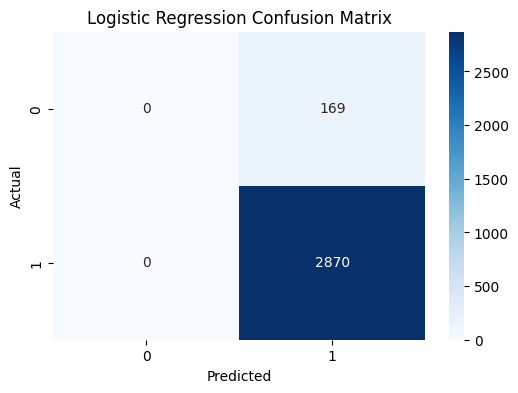

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, models["Logistic Regression"])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

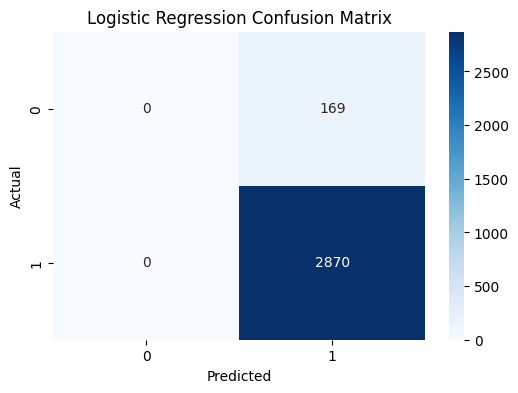

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, models["Logistic Regression"])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.savefig("confusion_matrix.png")
plt.show()

In [34]:
models

{'Logistic Regression': array([1, 1, 1, ..., 1, 1, 1]),
 'Decision Tree': array([1, 1, 1, ..., 1, 1, 1]),
 'Random Forest': array([1, 1, 1, ..., 1, 1, 1]),
 'Gradient Boosting': array([1, 1, 1, ..., 1, 1, 1])}

In [35]:
%whos

Variable                     Type                          Data/Info
--------------------------------------------------------------------
DecisionTreeClassifier       ABCMeta                       <class 'sklearn.tree._cla<...>.DecisionTreeClassifier'>
GradientBoostingClassifier   ABCMeta                       <class 'sklearn.ensemble.<...>dientBoostingClassifier'>
LogisticRegression           type                          <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
RandomForestClassifier       ABCMeta                       <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
X                            DataFrame                            window_length  dur<...>[15192 rows x 77 columns]
X_test                       DataFrame                            window_length  dur<...>n[3039 rows x 77 columns]
X_train                      DataFrame                            window_length  dur<...>[12153 rows x 77 columns]
accuracy                     float                       

In [36]:
lr = LogisticRegression(max_iter=1000)

In [37]:
import joblib

joblib.dump(lr, "best_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


In [38]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

In [39]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

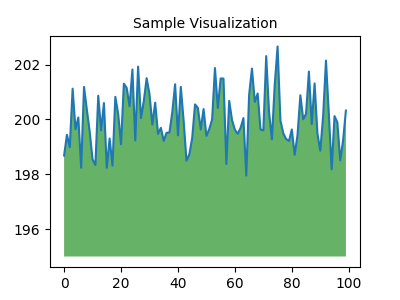

In [40]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)